# University of Ibadan Quantum Computing Club - Fall Fest 2026
## Introduction to Qiskit

In this notebook we will explore how we can program quantum gates and quantum circuits with Qiskit and even how we can execute them on simulators and real quantum computers using Qiskit patterns. Later we will introduce different ways of encoding information.

# Install Qiskit <a id="install"></a>

Quantum computers stand as a technology that promises to disrupt how some calculations are done - from breaking encryption with Shor's algorithm, to enabling faster searches with Grover's algorithm, to designing better batteries with quantum phase estimation. A first step is choosing a software tool for designing and executing such algorithms. Here we will use Qiskit for the design and implementation of quantum circuits in simulators and real hardware. The following will help you install Qiskit v2.0.

If you would prefer to follow a video guide on how to install and run Qiskit locally, watch [this video](https://www.youtube.com/watch?v=dZWz4Gs_BuI) to walk you through every step of the process.

First, check that the version of Python you are using in your environment is python>=3.10, to make sure that it is compatible with the latest Qiskit version:

In [ ]:
from platform import python_version

print(python_version())

If you need to upgrade Python and are unsure how to do it, please refer to this guide on how to upgrade Python depending on your OS: [How to update Python](https://4geeks.com/how-to/how-to-update-python-version).

Then, proceed to execute the next cell to [install the Qiskit SDK and the Qiskit Runtime client](https://quantum.cloud.ibm.com/docs/en/guides/install-qiskit)

In [ ]:
### INSTALL QISKIT: Visualization (works on all environments and cloud ###
%pip install qiskit
%pip install qiskit[visualization]
%pip install qiskit-ibm-runtime
%pip install matplotlib
%pip install qiskit_aer
%pip install pylatexenc
%pip install seaborn

## Troubleshooting <a id="troubleshooting"></a>

If the previous cell raised an error, you can opt to install Qiskit in a virtual environment (two suggested methods follow). If you have no errors, you can ignore this cell and proceed to the next one.

Here we propose two different methods to set up a virtual environment to install Qiskit.
1. Using [venv](https://docs.python.org/3/library/venv.html), as explained in the [Qiskit installation guide](https://docs.quantum.ibm.com/guides/install-qiskit).
2. Using [conda](https://docs.conda.io/projects/conda/en/latest/user-guide/install/index.html), as explained in this video of [Coding with Qiskit](https://www.youtube.com/watch?v=93-zLTppFZw&list=PLOFEBzvs-VvrgHZt3exM_NNiNKtZlHvZi&index=4).


Alternative options for using Qiskit are cloud platforms like [qBraid](https://qbraid.com/) and [Google Colab](https://colab.research.google.com/). If you're on a Windows device, a cloud platform may give you the the best experience, especially if you want to use a library that is incompatible with Windows, such as [ffsim](https://qiskit-community.github.io/ffsim/), which is useful for Quantum Chemistry applications.


## Imports <a id="imports"></a>

In [ ]:
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime import EstimatorV2 as Estimator
import matplotlib.pyplot as plt
from qiskit.quantum_info import Statevector

from qiskit.visualization import plot_bloch_multivector, plot_state_qsphere
from qiskit_aer import AerSimulator
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

In [ ]:
# CHECK QISKIT VERSION
import qiskit

qiskit.__version__

You should have Qiskit version `>=2.0.0`

# Set up your IBM Cloud account <a id="setting-ibm-cloud"> </a>

You must set up an IBM Cloud account in order to to execute quantum circuits on real hardware.

Follow the instructions in this guide [Set up your IBM Cloud account](https://quantum.cloud.ibm.com/docs/en/guides/cloud-setup) to complete the following steps:

1. Set up an IBM Cloud account if you do not already have one.
2. Log into or create an [IBM Quantum Platform](https://quantum.cloud.ibm.com/) account with an IBMid.
2. Access your IBM Quantum Platform dashboard, **create your API token**, and copy it to a secure location. (See first reference image below.)
3. In the code cell following the reference images, replace `deleteThisAndPasteYourAPIKeyHere` with your API key.
4. Go to the Instances page from the ☰ main menu and **create your instance**. If you are not part of a Network institution, choose the open plan. (See second reference image below.)
5. After the instance is created, copy its associated CRN code. (CRN stands for _Cloud Resource Names_) You may need to refresh to see the instance.
6.  In the code cell following the reference images, replace `deleteThisAndPasteYourCRNHere` with your CRN code.

<div class="alert alert-block alert-warning">
    
⚠️ **Note:** Treat your API key as you would a secure password. See the [Cloud setup](https://quantum.cloud.ibm.com/docs/guides/cloud-setup#cloud-save) guide for more information about using your API key in both secure and untrusted environments.
</div>

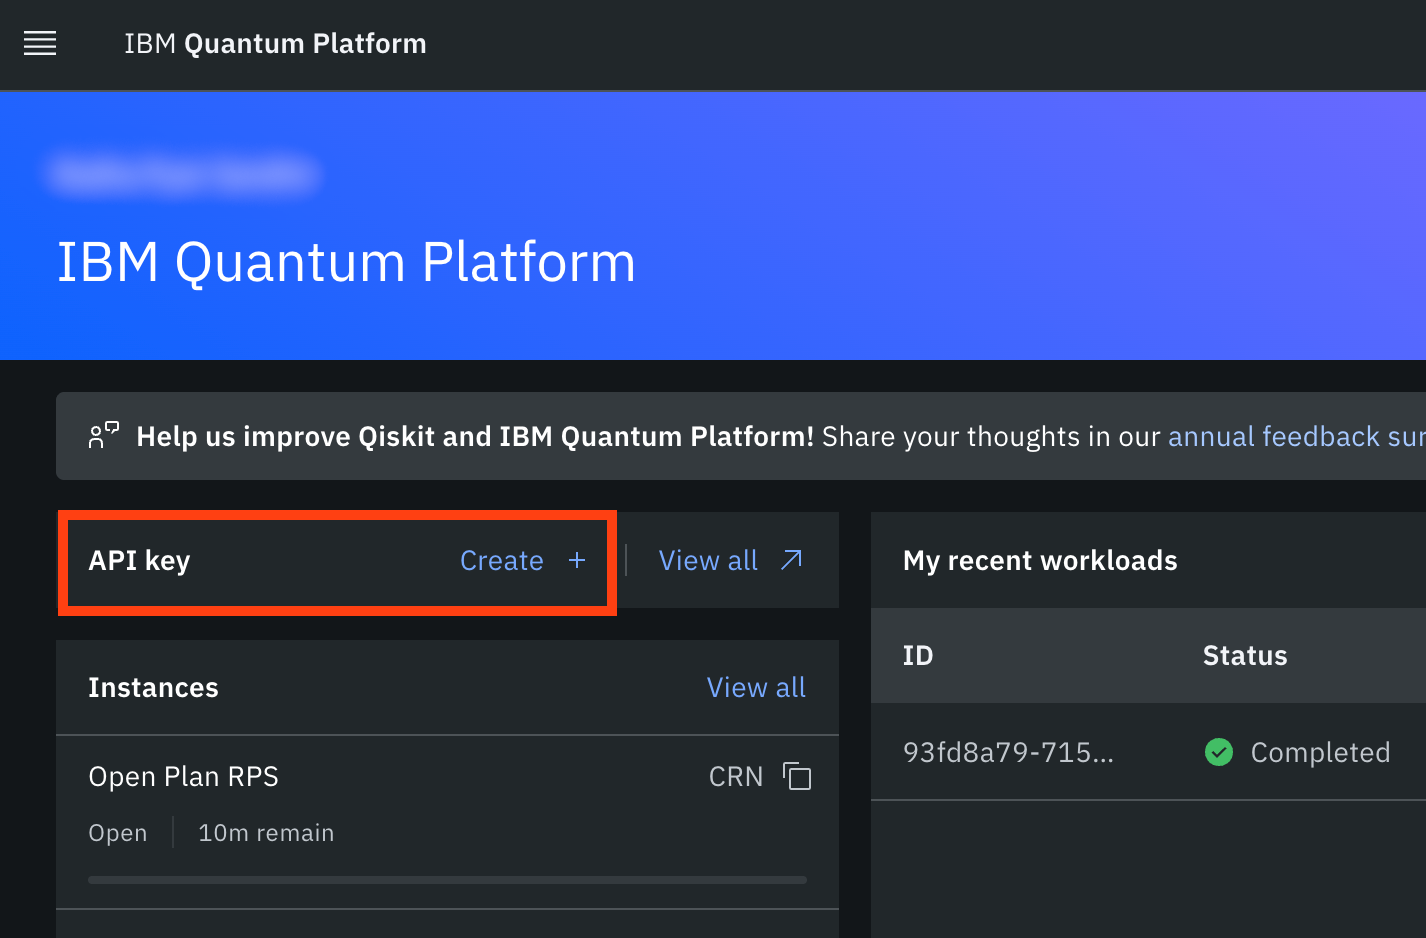

In [ ]:
your_api_key = "deleteThisAndPasteYourAPIKeyHere"
your_crn = "deleteThisAndPasteYourCRNHere"

QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token=your_api_key,
    instance=your_crn,
    overwrite=True
 )

# 1. Quantum Gates and Quantum Circuits
Quantum circuits are models for quantum computation in which a computation is a sequence of quantum gates. Let's take a look at some of the popular quantum gates.

### X Gate
An X gate equates to a rotation around the X-axis of the Bloch sphere by $\pi$ radians.
It maps $|0\rangle$ to $|1\rangle$ and $|1\rangle$ to $|0\rangle$. It is the quantum equivalent of the NOT gate for classical computers and is sometimes called a bit-flip.

$X = \begin{pmatrix}
0 & 1 \\
1 & 0 \\
\end{pmatrix}$

In [ ]:
# Let's apply an X-gate on a |0> qubit
qc = QuantumCircuit(1)
qc.x(0)
qc.draw("mpl")

In [ ]:
# Let's see Bloch sphere visualization
sv = Statevector(qc)
plot_bloch_multivector(sv)

### H Gate
A Hadamard gate represents a rotation of $\pi$ about the axis that is in the middle of the $X$-axis and $Z$-axis.
It maps the basis state $|0\rangle$ to $\frac{|0\rangle + |1\rangle}{\sqrt{2}}$, which means that a measurement will have equal probabilities of being `1` or `0`, creating a 'superposition' of states. This state is also written as $|+\rangle$.

$H = \frac{1}{\sqrt{2}}\begin{pmatrix}
1 & 1 \\
1 & -1 \\
\end{pmatrix}$

In [ ]:
# Let's apply an H-gate on a |0> qubit
qc = QuantumCircuit(1)
qc.x(0)
qc.h(0)
qc.draw(output="mpl")

In [ ]:
# Let's see Bloch sphere visualization
sv = Statevector(qc)
plot_bloch_multivector(sv)

### CX Gate (CNOT Gate)
The controlled NOT (or CNOT or CX) gate acts on two qubits. It performs the NOT operation (equivalent to applying an X gate) on the second qubit only when the first qubit is $|1\rangle$ and otherwise leaves it unchanged. Note: Qiskit numbers the bits in a string from right to left.

$CX = \begin{pmatrix}
1 & 0 & 0 & 0\\
0 & 1 & 0 & 0\\
0 & 0 & 0 & 1\\
0 & 0 & 1 & 0\\
\end{pmatrix}$

In [ ]:
# Let's apply a CX-gate on |11>
qc = QuantumCircuit(2)
qc.x(0)
qc.x(1)
qc.cx(0, 1)
qc.draw(output="mpl")

In [ ]:
sv = Statevector(qc)
plot_state_qsphere(sv)

<div class="alert alert-info">

  The Qiskit SDK uses the LSb 0 bit numbering where the $n^{th}$ digit has value $1 \ll n$ or $2^n$. For more details, see the [Bit-ordering in the Qiskit SDK](https://docs.quantum.ibm.com/guides/bit-ordering) topic.

</div>

Create the first Bell state

$$ |\phi^+ \rangle = \frac{1}{\sqrt 2}(|00 \rangle + |11 \rangle) $$


In [ ]:
# Create a Bell state circuit

qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)

# Draw the circuit
qc.draw("mpl")

In [ ]:
# Plot the state using q-sphere visualization
sv = Statevector(qc)
plot_state_qsphere(sv)
# q-sphere is useful for visualizing states when Bloch sphere fails to

Create the 3-qubit GHZ state

$$ |GHZ \rangle = \frac{1}{\sqrt 2}(|000 \rangle + |111 \rangle) $$



In [ ]:
# Create a circuit with 3-qubit GHZ state


qc = QuantumCircuit(3)
qc.h(0)
qc.cx(0, 1)
qc.cx(0, 2)


qc.draw("mpl")

In [ ]:
# Get the statevector of the circuit
sv = Statevector(qc)

# Plot the state using qsphere visualization
plot_state_qsphere(sv)

# 2. Create and run a simple quantum program



The four steps to writing a quantum program using Qiskit patterns are:

1.  Map the problem to a quantum-native format.

2.  Optimize the circuits and operators.

3.  Execute using a quantum primitive function.

4.  Analyze the results.

## 2.1 Map the problem to a quantum-native format

In a quantum program, *quantum circuits* are the native format in which to represent quantum instructions, and *operators* represent the observables to be measured. When creating a circuit, you'll usually create a new [`QuantumCircuit`](https://docs.quantum.ibm.com/api/qiskit/qiskit.circuit.QuantumCircuit#quantumcircuit-class) object, then add instructions to it in sequence.



The following code cell creates a circuit that produces the GHZ state which is a state wherein three qubits are fully entangled with each other.




In [ ]:
# Create a GHZ state circuit

qc = QuantumCircuit(3)
qc.h(0)
qc.cx(0, 1)
qc.cx(0, 2)
# Draw the circuit
qc.draw("mpl")

See [`QuantumCircuit`](https://docs.quantum.ibm.com/api/qiskit/qiskit.circuit.QuantumCircuit#quantumcircuit-class) in the documentation for all available operations.



When creating quantum circuits, you must also consider what type of data you want returned after execution. Qiskit provides two ways to return data: you can obtain a probability distribution for a set of qubits you choose to measure, or you can obtain the expectation value of an observable. Prepare your workload to measure your circuit in one of these two ways with [Qiskit primitives](https://docs.quantum.ibm.com/guides/get-started-with-primitives) (explained in detail in Step 3).

This example measures expectation values by using the `qiskit.quantum_info` submodule, which is specified by using operators (mathematical objects used to represent an action or process that changes a quantum state). The following code cell creates six three-qubit Pauli operators: `ZZZ`, `ZZX`, `ZII`, `XXI`, `ZZI` and `III`.


In [ ]:
# Set up six different observables.

observables_labels = ["ZZZ", "ZZX", "ZII", "XXI", "ZZI", "III"]

observables = [SparsePauliOp(label) for label in observables_labels]
print(observables)

<div class="alert alert-info">

  Here, something like the `ZZI` operator is a shorthand for the tensor product $Z\otimes Z\otimes I$, which means measuring Z on qubit 2 and Z on qubit 1 together, and obtaining information about the correlation between qubit 2 and qubit 1. Expectation values like this are also typically written as $\langle Z_2 Z_1 \rangle$.

  If the state we observe is the three-qubit GHZ state, then the measurement of $\langle Z_2 Z_1 \rangle$ should be 1.

</div>



<span id="optimize" />

## 2.2 Optimize the circuits and operators

When executing circuits on a device, it is important to optimize the set of instructions that the circuit contains and minimize the overall depth (roughly the number of instructions) of the circuit. This ensures that you obtain the best results possible by reducing the effects of error and noise. Additionally, the circuit's instructions must conform to a backend device's [Instruction Set Architecture (ISA)](https://docs.quantum.ibm.com/guides/transpile#instruction-set-architecture) and must consider the device's basis gates and qubit connectivity.

The following code instantiates a real device to submit a job to and transforms the circuit and observables to match that backend's ISA.

If you have not previously saved your credentials, follow instructions [here](https://docs.quantum.ibm.com/guides/setup-channel#iqp) to authenticate with your API token.

### Choosing a backend:

There are 3 main options for choosing a backend:
- Option 1: [Real hardware device](https://quantum.cloud.ibm.com/docs/en/guides/qpu-information)
- Option 2: [AerSimulator](https://qiskit.github.io/qiskit-aer/stubs/qiskit_aer.AerSimulator)
- Option 3: [Fake Provider](https://quantum.cloud.ibm.com/docs/en/api/qiskit-ibm-runtime/fake-provider)

Both Option 2 and Option 3 are classical simulators of the real quantum devices. Only Option 1 will execute a job on real hardware. While you will want to execute your circuits on real hardware in this Hackathon, the simulators are a very useful tool especially for testing and troubleshooting your code. So, we will first show how to execute a job using Option 2 - the AerSimulator and then we will show how to execute a job using Option 1 - the real hardware.

We start by showing how to initialize all three backend options:

#### Option 1: Real Hardware

In [ ]:
# Choose the least busy real backend
service = QiskitRuntimeService(channel='ibm_quantum_platform',)
backend = service.least_busy(min_num_qubits=156)
# print backend details
print(
    f"Name: {backend.name}\n"
    f"Version: {backend.backend_version}\n"
    f"No. of qubits: {backend.num_qubits}\n"
    f"Processor type: {backend.processor_type}\n"
)

#### Option 2: AerSimulator

In [ ]:
# option to use the AerSimulator instead of a real quantum device
seed_sim=42
backend_aer = AerSimulator.from_backend(backend,seed_simulator=seed_sim)

#### Option 3: Fake Backend

In [ ]:
from qiskit_ibm_runtime.fake_provider import FakeFez

# Get a fake backend from the fake provider
backend_fake = FakeFez()

Transpile the circuit into ISA circuit

In [ ]:
# Convert to an ISA circuit and layout-mapped observables.

pm = generate_preset_pass_manager(backend=backend, optimization_level=2)
isa_circuit = pm.run(qc)

isa_circuit.draw("mpl", idle_wires=False)

In [ ]:
mapped_observables = [
    observable.apply_layout(isa_circuit.layout) for observable in observables
]
print(mapped_observables)

## 2.3 Execute using the quantum primitives

Quantum computers can produce random results, so you usually collect a sample of the outputs by running the circuit many times. You can estimate the value of the observable by using the `Estimator` class. `Estimator` is one of two [primitives](https://docs.quantum.ibm.com/guides/get-started-with-primitives); the other is `Sampler`, which can be used to get data from a quantum computer.  These objects possess a `run()` method that executes the selection of circuits, observables, and parameters (if applicable), using a [primitive unified bloc (PUB).](https://docs.quantum.ibm.com/guides/primitives#sampler)

When running this code on real quantum hardware, consider applying [error mitigation and suppression techniques](https://quantum.cloud.ibm.com/docs/en/guides/error-mitigation-and-suppression-techniques) to reduce the quantum computer's intrinsic noise.

In [ ]:
# Construct the Estimator instance.
estimator = Estimator(mode=backend)
estimator.options.resilience_level = 1
estimator.options.default_shots = 5000

Submit a job using the Estimator primitive.


In [ ]:
# One pub, with one circuit to run against six different observables.
job = estimator.run([(isa_circuit, mapped_observables)])


# Use the job ID to retrieve your job data later
print(f">>> Job ID: {job.job_id()}")

After a job is submitted, you can wait until either the job is completed within your current python instance, or use the `job_id` to retrieve the data at a later time.  (See the [section on retrieving jobs](https://docs.quantum.ibm.com/guides/monitor-job#retrieve-job-results-at-a-later-time) for details.)

After the job completes, examine its output through the job's `result()` attribute.



In [ ]:
print(f"status: {job.status()}")

In [ ]:
# This is the result of the entire submission.  You submitted one Pub,
# so this contains one inner result (and some metadata of its own).
job_result = job.result()

# This is the result from our single pub, which had six observables,
# so contains information on all six.
pub_result = job.result()[0]

Now we can also execute the circuit using the `Sampler` primitive

In [ ]:
# We include the measurements in the circuit
qc.measure_all()
sampler = Sampler(mode=backend)

In [ ]:
qc.draw(output="mpl")

Submit a job using the Sampler primitive.

In [ ]:
job_sampler = sampler.run(pm.run([qc]))

# Use the job ID to retrieve your job data later
print(f">>> Job ID: {job_sampler.job_id()}")

In [ ]:
print(f"status: {job_sampler.status()}")

In [ ]:
# Get the results
results_sampler = job_sampler.result()

## 2.4 Analyze the results

The analyze step is typically where you might postprocess your results using, for example, measurement error mitigation or zero noise extrapolation (ZNE). You might feed these results into another workflow for further analysis or prepare a plot of the key values and data. In general, this step is specific to your problem.  For this example, plot each of the expectation values that were measured for our circuit.

The expectation values and standard deviations for the observables you specified to Estimator are accessed through the job result's `PubResult.data.evs` and `PubResult.data.stds` attributes. To obtain the results from Sampler, use the `PubResult.data.meas.get_counts()` function, which will return a `dict` of measurements in the form of bitstrings as keys and counts as their corresponding values. For more information, see [Get started with Sampler.](https://docs.quantum.ibm.com/guides/get-started-with-primitives#get-started-with-sampler)



In [ ]:
# Plot the result
values = pub_result.data.evs
errors = pub_result.data.stds
# plotting graph
# Plotting with error bars
plt.errorbar(observables_labels, values, yerr=errors, fmt="-o", capsize=5)
plt.xlabel("Observables")
plt.ylabel("Values")
plt.title("Plot of Observables vs Values with Error Bars")
plt.grid(True)
plt.tight_layout()
plt.show()

We see that the observables $ZZI$ and $III$ have an expectation value of 1, since $ZZI$ introduces two minus signs that cancel out, and $III$ acts as the identity, leaving the GHZ state unchanged. The rest of the observables have an expectation value of 0, since their $Z$ operators introduce an odd number of minus signs, or the $X$ operators flip a number of qubits that make the overlapping states orthogonal.



Now we plot the results for the Sampler

In [ ]:
counts_list = results_sampler[0].data.meas.get_counts()
print(counts_list)
print(f"Outcomes : {counts_list}")
display(plot_histogram(counts_list, title="GHZ state"))

## 2.5 Scale to large numbers of qubits

In quantum computing, utility-scale work is crucial for making progress in the field. Such work requires computations to be done on a much larger scale; working with circuits that might use over 100 qubits and over 1000 gates. This example takes a small step in that direction scaling the GHZ problem to $n=10$ qubits.  It uses the Qiskit patterns workflow and ends by measuring the expectation value $\langle Z_0 Z_i \rangle $ for each qubit.

### Step 1. Map the problem

Write a function that returns a `QuantumCircuit` that prepares an $n$-qubit GHZ state (essentially an extended Bell state), then use that function to prepare a 10-qubit GHZ state and collect the observables to be measured.


In [ ]:
def get_qc_for_n_qubit_GHZ_state(n: int) -> QuantumCircuit:

    qc = QuantumCircuit(n)
    qc.h(0)
    for i in range(n - 1):
        qc.cx(i, i + 1)
    return qc


n = 10
qc_n_GHZ = get_qc_for_n_qubit_GHZ_state(n)
qc_n_GHZ.draw("mpl")

Next, map to the operators of interest. This example uses the `ZZ` operators between qubits to examine the behavior as they get farther apart.  Increasingly inaccurate (corrupted) expectation values between distant qubits would reveal the level of noise present.


In [ ]:
# ZZII...II, ZIZI...II, ... , ZIII...IZ
operator_strings = ["Z" + i * "I" + "Z" + "I" * (n - i - 2) for i in range(n - 1)]
print(operator_strings)
print(len(operator_strings))

operators = [SparsePauliOp(operator) for operator in operator_strings]

### Step 2. Optimize the problem for execution on quantum backend

Transform the circuit and observables to match the backend's ISA.



In [ ]:
# Convert to an ISA circuit and layout-mapped observables.
pm = generate_preset_pass_manager(backend=backend, optimization_level=2)
isa_circuit = pm.run(qc_n_GHZ)
isa_operators_list = [
    operator.apply_layout(isa_circuit.layout) for operator in operators
]

### Step 3. Execute on backend

Submit the job and if you execute it on hardware enable error suppression by using a technique to reduce errors called [dynamical decoupling.](https://docs.quantum.ibm.com/api/qiskit-ibm-runtime/options-dynamical-decoupling-options) The resilience level specifies how much resilience to build against errors. Higher levels generate more accurate results, at the expense of longer processing times.  For further explanation of the options set in the following code, see [Configure error mitigation for Qiskit Runtime.](https://docs.quantum.ibm.com/guides/configure-error-mitigation)



In [ ]:
# Submit the circuit to Estimator
job = estimator.run([(isa_circuit, isa_operators_list)])
job_id = job.job_id()

In [ ]:
print(f"status: {job.status()}")

### Step 4. Post-process results

To better understand the behavior of entangled quantum states on real hardware, we analyze the pairwise correlations between qubits in the Z basis. Specifically, we look at the expectation values ⟨Z₀Zᵢ⟩, which measure how strongly qubit 0 is correlated with each other qubit i. In particular we are going to plot:
$$
\langle Z_i Z_0 \rangle / \langle Z_1 Z_0 \rangle
$$

In [ ]:
data = list(range(1, len(operators) + 1))  # Distance between the Z operators
result = job.result()[0]
values = result.data.evs  # Expectation value at each Z operator.
values = [
    v / values[0] for v in values
]  # Normalize the expectation values to evaluate how they decay with distance.

plt.plot(data, values, marker="o", label=f"{n}-qubit GHZ state")
plt.xlabel("Distance between qubits $i$")
plt.ylabel(r"$\langle Z_i Z_0 \rangle / \langle Z_1 Z_0 \rangle $")
plt.legend()
plt.show()

In this plot we notice that $\langle Z_0 Z_i \rangle$ fluctuates around the value 1, even though in an ideal simulation all $\langle Z_0 Z_i \rangle$ should be 1.



As you can see, the results of 10 qubit experiments are good but still have some errors. One way to improve the results is to implement GHZ state more efficiently.

Usually one implements GHZ state with a staircase-like CNOT gates sequence. However, you can implement GHZ state more efficiently, reducing the 2-qubit depth from `n` to `n/2` or less.

<div class="alert alert-info">

One important metric to benchmark how accurate the results will be, or how little noise will have for a circuit is 2-qubit gate depth. This is because the error rates for 2-qubit gates (~10 times higher than single qubit gates) dominate the errors of the whole circuit. Use the following code to get 2-qubit gate depth of a circuit.

```
qc.depth(lambda x: x.operation.num_qubits == 2)
```

</div>

In [ ]:
def better_ghz(n):
    "fan out"
    s = int(n / 2)
    qc = QuantumCircuit(n)
    qc.h(s)
    for m in range(s, 0, -1):
        qc.cx(m, m - 1)
        if not (n % 2 == 0 and m == s):
            qc.cx(n - m - 1, n - m)
    return qc


better_ghz(n).draw("mpl")

In [ ]:
# Check 2-qubit gate depth before transpilation
qc_better_ghz = better_ghz(n)
qc_better_ghz.depth(lambda x: x.operation.num_qubits == 2)

An interesting thing to note here is that we were able to reduce the [**quantum depth**](https://www.youtube.com/watch?v=7AVIc7SkX3M) of the circuit we want to execute just by being smart and thinking of a different way to program it. However, there will be situations and algorithms where we can't rely on these clever tricks. This is where the transpiler comes in handy, it helps us optimize all these aspects efficiently, so we don't have to worry too much about them.

# Conclusion

In this notebook, you have learned how to construct quantum circuits, from building quantum gates to defining and measuring observables, and how to execute these circuits efficiently on both simulators and actual quantum hardware. You have also seen the importance of careful circuit design in order to minimize errors when working with real quantum devices as well as strategies for scaling circuits to larger numbers of qubits, particularly through the GHZ state example. With all this, you are fully equipped to start working with quantum algorithms.